In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/engineered_weather.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)

(8647, 45)


In [2]:
def rolling_mad_score(series, window=24, min_periods=12):
    
    rolling_median = (
        series
        .shift(1)
        .rolling(
            window=window,
            min_periods=min_periods
        )
        .median()
    )
    
    rolling_mad = (
        series
        .shift(1)
        .rolling(
            window=window,
            min_periods=min_periods
        )
        .apply(
            lambda x: np.median(
                np.abs(x - np.median(x))
            ),
            raw=True
        )
    )
    
    robust_std = 1.4826 * rolling_mad
    
    score = (
        np.abs(series - rolling_median) /
        (robust_std + 1e-6)
    )
    
    return score

In [3]:
for col in ["temp", "rhum", "wspd", "pres"]:
    
    df[f"{col}_mad_score"] = rolling_mad_score(
        df[col]
    )

In [4]:
df[
    [
        "timestamp",
        "temp",
        "temp_mad_score",
        "rhum",
        "rhum_mad_score"
    ]
].head(30)

,timestamp,temp,temp_mad_score,rhum,rhum_mad_score
0,2024-01-01 00:00:00,20.8,NaN,84,NaN
1,2024-01-01 01:00:00,23.6,NaN,69,NaN
2,2024-01-01 02:00:00,23.9,NaN,65,NaN
3,2024-01-01 03:00:00,22.6,NaN,69,NaN
4,2024-01-01 04:00:00,28.2,NaN,48,NaN
5,2024-01-01 05:00:00,30.4,NaN,39,NaN
6,2024-01-01 06:00:00,31.4,NaN,36,NaN
7,2024-01-01 07:00:00,33.3,NaN,40,NaN
8,2024-01-01 08:00:00,33.6,NaN,45,NaN
9,2024-01-01 09:00:00,32.0,NaN,35,NaN


In [5]:
for col in ["temp", "rhum", "wspd", "pres"]:
    
    df[f"{col}_stat_anomaly"] = (
        df[f"{col}_mad_score"] > 3.5
    )

In [6]:
stat_columns = [
    "temp_stat_anomaly",
    "rhum_stat_anomaly",
    "wspd_stat_anomaly",
    "pres_stat_anomaly"
]

df["statistical_anomaly"] = (
    df[stat_columns]
    .any(axis=1)
)

In [7]:
print(
    df["statistical_anomaly"]
    .value_counts()
)

statistical_anomaly
False    8250
True      397
Name: count, dtype: int64


In [8]:
weather_columns = [
    "temp",
    "rhum",
    "prcp",
    "wdir",
    "wspd",
    "pres",
    "cldc",
    "coco"
]

df["missing_anomaly"] = (
    df[weather_columns]
    .isnull()
    .any(axis=1)
)

In [9]:
print(
    df["missing_anomaly"]
    .value_counts()
)

missing_anomaly
False    8577
True       70
Name: count, dtype: int64


In [10]:
df["rhum_invalid"] = (
    (df["rhum"] < 0) |
    (df["rhum"] > 100)
)

df["wspd_invalid"] = (
    df["wspd"] < 0
)

df["wdir_invalid"] = (
    (df["wdir"] < 0) |
    (df["wdir"] > 360)
)

df["prcp_invalid"] = (
    df["prcp"] < 0
)

df["cldc_invalid"] = (
    (df["cldc"] < 0) |
    (df["cldc"] > 8)
)

df["rule_anomaly"] = (
    df["rhum_invalid"] |
    df["wspd_invalid"] |
    df["wdir_invalid"] |
    df["prcp_invalid"] |
    df["cldc_invalid"]
)

In [11]:
from sklearn.ensemble import IsolationForest

In [12]:
ml_features = [
    "temp",
    "rhum",
    "prcp",
    "wspd",
    "pres",
    "cldc",
    "wdir_sin",
    "wdir_cos",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "temp_diff",
    "rhum_diff",
    "wspd_diff",
    "pres_diff",
    "temp_deviation",
    "rhum_deviation",
    "wspd_deviation",
    "pres_deviation"
]

In [13]:
X = df[ml_features].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median()
)

In [14]:
print("Remaining missing values:")
print(X.isnull().sum().sum())

Remaining missing values:
0


In [15]:
isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [16]:
df["if_prediction"] = (
    isolation_model.predict(X)
)

In [17]:
df["if_anomaly"] = (
    df["if_prediction"] == -1
)

In [18]:
df["if_score"] = (
    -isolation_model.score_samples(X)
)

In [19]:
print(
    df["if_score"].describe()
)

count    8647.000000
mean        0.474157
std         0.028571
min         0.418316
25%         0.452823
50%         0.469103
75%         0.490458
max         0.603658
Name: if_score, dtype: float64


In [20]:
top_anomalies = (
    df.sort_values(
        "if_score",
        ascending=False
    )
    [
        [
            "timestamp",
            "temp",
            "rhum",
            "wspd",
            "pres",
            "if_score"
        ]
    ]
    .head(20)
)

top_anomalies

,timestamp,temp,rhum,wspd,pres,if_score
987,2024-02-11 03:00:00,19.4,74,1.8,1016.8,0.603658
8296,2024-12-17 09:00:00,33.6,18,0.0,1009.5,0.601776
7533,2024-11-14 16:00:00,25.3,86,29.2,1013.7,0.597154
963,2024-02-10 03:00:00,21.0,72,3.6,1016.3,0.594382
1584,2024-03-07 00:00:00,18.0,86,1.8,1011.7,0.591173
1224,2024-02-21 00:00:00,18.4,86,1.8,1012.0,0.590928
981,2024-02-10 21:00:00,20.0,81,5.4,1014.4,0.590349
5664,2024-08-24 00:00:00,25.0,96,1.8,1007.5,0.588257
1296,2024-02-24 00:00:00,18.6,90,1.8,1010.7,0.587051
1722,2024-03-12 18:00:00,24.0,87,3.6,1013.8,0.585053


In [21]:
df["stat_score"] = (
    df[
        [
            "temp_mad_score",
            "rhum_mad_score",
            "wspd_mad_score",
            "pres_mad_score"
        ]
    ]
    .max(axis=1)
)

In [22]:
df["rule_score"] = (
    df["rule_anomaly"].astype(int)
)

In [23]:
df["missing_score"] = (
    df["missing_anomaly"].astype(int)
)

In [24]:
if_min = df["if_score"].min()
if_max = df["if_score"].max()

df["if_score_norm"] = (
    (df["if_score"] - if_min) /
    (if_max - if_min + 1e-9)
)

In [25]:
stat_min = df["stat_score"].min()
stat_max = df["stat_score"].max()

df["stat_score_norm"] = (
    (df["stat_score"] - stat_min) /
    (stat_max - stat_min + 1e-9)
)

In [26]:
df["fusion_score"] = (
    0.45 * df["if_score_norm"] +
    0.35 * df["stat_score_norm"] +
    0.10 * df["missing_score"] +
    0.10 * df["rule_score"]
)

In [27]:
df["final_anomaly"] = (
    df["fusion_score"] >= 0.70
)

In [28]:
print(
    df["final_anomaly"]
    .value_counts()
)

final_anomaly
False    8647
Name: count, dtype: int64


In [29]:
print(
    "Final anomaly rate:",
    round(
        df["final_anomaly"].mean() * 100,
        2
    ),
    "%"
)

Final anomaly rate: 0.0 %


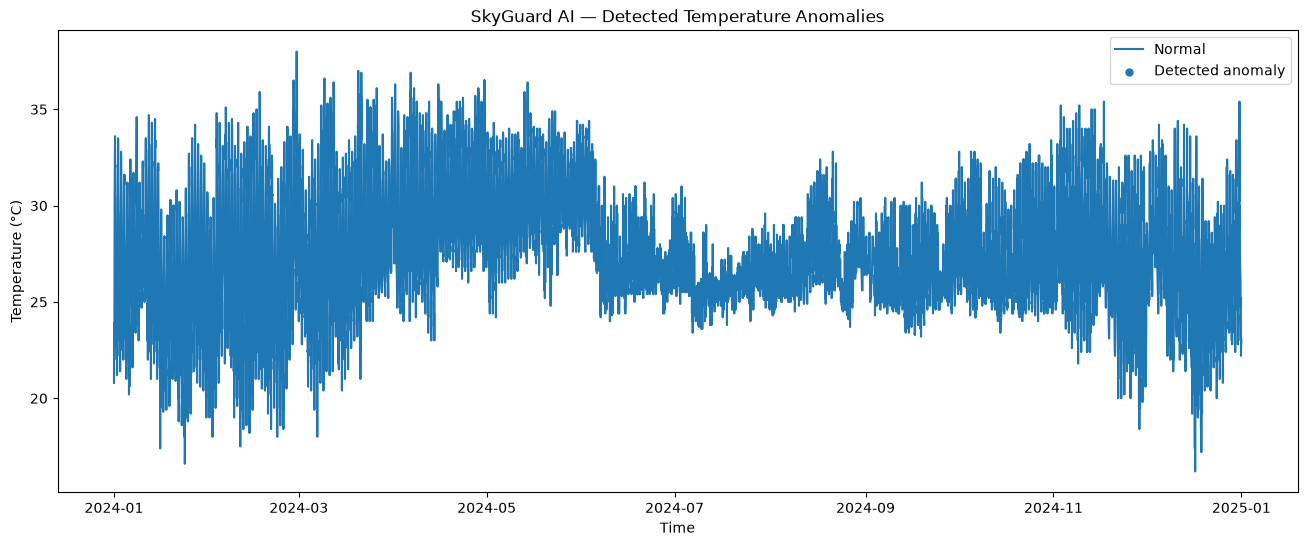

In [30]:
plt.figure(figsize=(16, 6))

normal = ~df["final_anomaly"]
anomaly = df["final_anomaly"]

plt.plot(
    df.loc[normal, "timestamp"],
    df.loc[normal, "temp"],
    label="Normal"
)

plt.scatter(
    df.loc[anomaly, "timestamp"],
    df.loc[anomaly, "temp"],
    label="Detected anomaly",
    s=25
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("SkyGuard AI — Detected Temperature Anomalies")
plt.legend()
plt.show()

In [31]:
df.to_csv(
    "../data/anomaly_results.csv",
    index=False
)

print("Anomaly results saved successfully.")

Anomaly results saved successfully.


In [32]:
print("Rule anomalies:")
print(df["rule_anomaly"].value_counts())

print("\nMissing-data anomalies:")
print(df["missing_anomaly"].value_counts())

print("\nStatistical anomalies:")
print(df["statistical_anomaly"].value_counts())

print("\nIsolation Forest anomalies:")
print(df["if_anomaly"].value_counts())

Rule anomalies:
rule_anomaly
False    8647
Name: count, dtype: int64

Missing-data anomalies:
missing_anomaly
False    8577
True       70
Name: count, dtype: int64

Statistical anomalies:
statistical_anomaly
False    8250
True      397
Name: count, dtype: int64

Isolation Forest anomalies:
if_anomaly
False    8474
True      173
Name: count, dtype: int64


In [33]:
print(df["fusion_score"].describe())

count    8623.000000
mean        0.178513
std         0.085192
min         0.006683
25%         0.114731
50%         0.163833
75%         0.228530
max         0.578595
Name: fusion_score, dtype: float64


In [35]:
top_fusion = (
    df.sort_values(
        "fusion_score",
        ascending=False
    )
    [
        [
            "timestamp",
            "temp",
            "rhum",
            "wspd",
            "pres",
            "if_score",
            "stat_score",
            "fusion_score"
        ]
    ]
    .head(20)
)

top_fusion

,timestamp,temp,rhum,wspd,pres,if_score,stat_score,fusion_score
2205,2024-04-01 21:00:00,25.6,90,1.8,1008.8,0.512468,12.692682,0.578595
2367,2024-04-08 15:00:00,27.4,84,5.4,1009.4,0.504234,12.692682,0.558603
8269,2024-12-16 06:00:00,31.2,20,1.8,1014.2,0.582814,5.545811,0.550025
4833,2024-07-20 09:00:00,24.4,96,7.6,1004.9,0.518238,10.791779,0.539578
2208,2024-04-02 00:00:00,24.7,90,5.4,1008.3,0.512579,11.196539,0.537130
1722,2024-03-12 18:00:00,24.0,87,3.6,1013.8,0.585053,4.669550,0.531018
8144,2024-12-10 09:00:00,34.0,38,3.6,1009.3,0.568716,2.492683,0.530629
8152,2024-12-11 09:00:00,34.4,33,5.4,1009.8,0.559353,3.192589,0.527419
4683,2024-07-14 03:00:00,26.0,95,1.8,1004.2,0.546064,7.890267,0.526200
1680,2024-03-11 00:00:00,21.2,65,0.0,1013.5,0.562457,6.420151,0.524991


In [36]:
print("Maximum Isolation Forest normalized score:")
print(df["if_score_norm"].max())

print("\nMaximum statistical normalized score:")
print(df["stat_score_norm"].max())

print("\nMaximum missing score:")
print(df["missing_score"].max())

print("\nMaximum rule score:")
print(df["rule_score"].max())

Maximum Isolation Forest normalized score:
0.9999999946045932

Maximum statistical normalized score:
0.9999999999202986

Maximum missing score:
1

Maximum rule score:
0


In [37]:
df["fusion_score"] = (
    0.45 * df["if_score_norm"] +
    0.35 * df["stat_score_norm"] +
    0.10 * df["missing_score"] +
    0.10 * df["rule_score"]
)

In [38]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    
    count = (
        df["fusion_score"] >= threshold
    ).sum()
    
    percentage = (
        count / len(df) * 100
    )
    
    print(
        f"Threshold {threshold:.2f}: "
        f"{count} anomalies "
        f"({percentage:.2f}%)"
    )

Threshold 0.30: 794 anomalies (9.18%)
Threshold 0.40: 143 anomalies (1.65%)
Threshold 0.50: 19 anomalies (0.22%)
Threshold 0.60: 0 anomalies (0.00%)
Threshold 0.70: 0 anomalies (0.00%)


In [39]:
print(df["if_anomaly"].value_counts())
print(df["statistical_anomaly"].value_counts())
print(df["missing_anomaly"].value_counts())

if_anomaly
False    8474
True      173
Name: count, dtype: int64
statistical_anomaly
False    8250
True      397
Name: count, dtype: int64
missing_anomaly
False    8577
True       70
Name: count, dtype: int64


In [40]:
print(df["fusion_score"].describe())

count    8623.000000
mean        0.178513
std         0.085192
min         0.006683
25%         0.114731
50%         0.163833
75%         0.228530
max         0.578595
Name: fusion_score, dtype: float64


In [41]:
print(
    df.sort_values(
        "fusion_score",
        ascending=False
    )[
        [
            "timestamp",
            "temp",
            "rhum",
            "wspd",
            "pres",
            "if_score_norm",
            "stat_score_norm",
            "fusion_score"
        ]
    ].head(10)
)

               timestamp  temp  rhum  wspd    pres  if_score_norm  \
2205 2024-04-01 21:00:00  25.6    90   1.8  1008.8       0.507990   
2367 2024-04-08 15:00:00  27.4    84   5.4  1009.4       0.463562   
8269 2024-12-16 06:00:00  31.2    20   1.8  1014.2       0.887535   
4833 2024-07-20 09:00:00  24.4    96   7.6  1004.9       0.539122   
2208 2024-04-02 00:00:00  24.7    90   5.4  1008.3       0.508590   
1722 2024-03-12 18:00:00  24.0    87   3.6  1013.8       0.899616   
8144 2024-12-10 09:00:00  34.0    38   3.6  1009.3       0.811472   
8152 2024-12-11 09:00:00  34.4    33   5.4  1009.8       0.760952   
4683 2024-07-14 03:00:00  26.0    95   1.8  1004.2       0.689257   
1680 2024-03-11 00:00:00  21.2    65   0.0  1013.5       0.777704   

      stat_score_norm  fusion_score  
2205         1.000000      0.578595  
2367         1.000000      0.558603  
8269         0.430385      0.550025  
4833         0.848496      0.539578  
2208         0.880755      0.537130  
1722        

In [42]:
print("IF + Statistical overlap:")
print(
    (
        df["if_anomaly"] &
        df["statistical_anomaly"]
    ).sum()
)

print("\nIF OR Statistical:")
print(
    (
        df["if_anomaly"] |
        df["statistical_anomaly"]
    ).sum()
)

print("\nIF + Statistical + Missing:")
print(
    (
        df["if_anomaly"] &
        df["statistical_anomaly"] &
        df["missing_anomaly"]
    ).sum()
)

IF + Statistical overlap:
29

IF OR Statistical:
541

IF + Statistical + Missing:
0


In [43]:
print(
    "Rows with missing fusion score:",
    df["fusion_score"].isna().sum()
)

print(
    df.loc[
        df["fusion_score"].isna(),
        ["timestamp", "temp", "rhum", "wspd", "pres"]
    ].head(30)
)

Rows with missing fusion score: 24
             timestamp  temp  rhum  wspd    pres
0  2024-01-01 00:00:00  20.8    84   5.4  1012.7
1  2024-01-01 01:00:00  23.6    69  10.1  1012.1
2  2024-01-01 02:00:00  23.9    65  10.8  1012.7
3  2024-01-01 03:00:00  22.6    69   5.4  1014.5
4  2024-01-01 04:00:00  28.2    48  10.4  1014.1
5  2024-01-01 05:00:00  30.4    39  11.5  1014.0
6  2024-01-01 06:00:00  31.4    36   7.6  1014.2
7  2024-01-01 07:00:00  33.3    40  15.1  1012.5
8  2024-01-01 08:00:00  33.6    45  17.6  1011.0
9  2024-01-01 09:00:00  32.0    35   9.4  1011.2
10 2024-01-01 10:00:00  32.1    54  19.4  1010.0
11 2024-01-01 11:00:00  30.3    57  15.1  1010.0
12 2024-01-01 12:00:00  29.4    55   5.4  1011.2
13 2024-01-01 13:00:00  27.5    65  14.0  1011.0
14 2024-01-01 14:00:00  27.1    70  16.2  1012.0
15 2024-01-01 15:00:00  26.2    70   3.6  1013.4
16 2024-01-01 16:00:00  26.4    71  20.2  1013.1
17 2024-01-01 17:00:00  25.8    74  19.8  1013.2
18 2024-01-01 18:00:00  24.0    78

In [44]:
df["fusion_score"] = (
    0.45 * df["if_score_norm"] +
    0.35 * df["stat_score_norm"] +
    0.10 * df["missing_score"] +
    0.10 * df["rule_score"]
)

In [45]:
df["candidate_anomaly"] = (
    (
        df["if_anomaly"] &
        df["statistical_anomaly"]
    )
    |
    df["missing_anomaly"]
    |
    df["rule_anomaly"]
)

In [46]:
print(
    df["candidate_anomaly"].value_counts()
)

candidate_anomaly
False    8548
True       99
Name: count, dtype: int64


In [47]:
print(
    "Candidate anomaly rate:",
    round(
        df["candidate_anomaly"].mean() * 100,
        2
    ),
    "%"
)

Candidate anomaly rate: 1.14 %


In [48]:
print("IF + Statistical overlap:")
print(
    (
        df["if_anomaly"] &
        df["statistical_anomaly"]
    ).sum()
)

print("\nIF OR Statistical:")
print(
    (
        df["if_anomaly"] |
        df["statistical_anomaly"]
    ).sum()
)

print("\nIF + Statistical + Missing:")
print(
    (
        df["if_anomaly"] &
        df["statistical_anomaly"] &
        df["missing_anomaly"]
    ).sum()
)

IF + Statistical overlap:
29

IF OR Statistical:
541

IF + Statistical + Missing:
0


In [49]:
df["candidate_anomaly"] = (
    (
        df["if_anomaly"] &
        df["statistical_anomaly"]
    )
    |
    df["missing_anomaly"]
    |
    df["rule_anomaly"]
)

print(df["candidate_anomaly"].value_counts())

print(
    "Candidate anomaly rate:",
    round(
        df["candidate_anomaly"].mean() * 100,
        2
    ),
    "%"
)

candidate_anomaly
False    8548
True       99
Name: count, dtype: int64
Candidate anomaly rate: 1.14 %


In [50]:
df.to_csv(
    "../data/anomaly_results.csv",
    index=False
)

print("Saved:", df.shape)

Saved: (8647, 72)
